<a href="https://colab.research.google.com/github/Ludashi47/Linked-data-OperaSampo/blob/main/BiographySampo_examples_Hack4OpenGlam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[BiographySampo](http://biografiasampo.fi/haku/ruudukko) open data query examples

# Environment setup

## *Install* the dependencies:

In [7]:
!pip install SPARQLWrapper numpy scipy matplotlib pandas networkx itables
%matplotlib inline

from datetime import datetime
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import numpy    as np
import networkx as nx
import pandas   as pd

from collections import Counter, OrderedDict
from itables import init_notebook_mode
from rdflib import URIRef
from rdflib.namespace import XSD, Namespace
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d
from SPARQLWrapper import SPARQLWrapper, JSON, POST
from IPython.display import display, HTML

from itertools import combinations
import seaborn as sns

## Define some useful functions for data conversion

In [8]:
from rdflib.namespace import XSD
import pandas as pd

DATATYPECONVERTERS = {
      str(XSD.integer):  int,
      str(XSD.decimal):  float,
      str(XSD.date):     lambda v: datetime.strptime(v, '%Y-%m-%d').date(),
      str(XSD.dateTime): lambda v: datetime.strptime(v, '%Y-%m-%dT%H:%M:%S').date()
  }

def convertDatatype(obj):
  return DATATYPECONVERTERS.get(obj.get('datatype'), str)(obj.get('value'))

def JSON2Pandas(results):
    res = results["results"]["bindings"]
    data = [dict([(k, convertDatatype(v)) for k,v in r.items()]) for r in res]
    return pd.DataFrame(data)

def convertDatatypes(results):
    res = results["results"]["bindings"]
    return [dict([(k, convertDatatype(v)) for k,v in r.items()]) for r in res]

## Constants for category example

In [9]:
CATS = Namespace('http://ldf.fi/nbf/categories/')

CATEGORY_LOOKUP = {
    CATS.c74: 'Economics',
    CATS.c75: 'Economics',
    CATS.c71: 'Economics',
    CATS.c72: 'Economics',
    CATS.c73: 'Economics',
    CATS.c76: 'Economics',
    CATS.c131: 'Politics',
    CATS.c132: 'Politics',
    CATS.c133: 'Politics',
    CATS.c39: 'Science',
    CATS.c38: 'Science',
    CATS.c381: 'Science',
    CATS.c382: 'Science',
    CATS.c34: 'Science',
    CATS.c341: 'Science',
    CATS.c342: 'Science',
    CATS.c31: 'Science',
    CATS.c37: 'Science', # 'theology')
    CATS.c35: 'Science',
    CATS.c33: 'Science',
    CATS.c32: 'Science',
    CATS.c36: 'Science',
    CATS.c44: 'Culture', # 'art and music',
    CATS.c41: 'Culture', # 'art and music',
    CATS.c43: 'Culture', # 'art and music',
    CATS.c46: 'Culture', # writers
    CATS.c47: 'Culture', # poets
    CATS.c42: 'Culture',
    CATS.c48: 'Culture', # kirjastot, arkistot, museot
    CATS.c45: 'Culture',
    CATS.c12: 'Military',
    CATS.c51: 'Sports',
    CATS.c52: 'Sports',
    CATS.c5121: 'Sports',
    CATS.c61: 'Religion', # 'lutherians')
    CATS.c62: 'Religion', # 'catholics')
    CATS.c63: 'Religion', # ortodoksit
    CATS.c64: 'Religion', # muut uskonnot
    CATS.c21: 'Education',
    CATS.c22: 'Education',
    CATS.c81: 'Communications',
    CATS.c82: 'Communications',
    CATS.c83: 'Communications',
    CATS.c101: 'Civil Servants',
    CATS.c102: 'Civil Servants',
    CATS.c103: 'Civil Servants',
    CATS.c91: 'Charitable and NGO',
    CATS.c92: 'Charitable and NGO',
    CATS.c93: 'Charitable and NGO',
    CATS.c94: 'Charitable and NGO',
    CATS.c111: 'Judiciary',
    CATS.c112: 'Judiciary'
}

# Querying venue data, including venueInstance, venue, city, lat, long, and performanceCount.


In [18]:
sparql = SPARQLWrapper("http://ldf.fi/operasampo/sparql")
sparql.setQuery("""
PREFIX os: <http://ldf.fi/schema/operasampo/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX wgs84_pos: <http://www.w3.org/2003/01/geo/wgs84_pos#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>


SELECT ?venue ?city ?lat ?long ?period ?venueInstance (COUNT(DISTINCT ?performance) AS ?performanceCount)
WHERE {
  ?performance a os:Performance .
  ?performance os:performanceDateStart ?date . #拿到演出日期
  ?performance os:performedIn ?venueInstance .
  ?venueInstance os:city ?city .
  ?venueInstance skos:prefLabel ?venue .
  ?venueInstance wgs84_pos:lat ?lat .
  ?venueInstance wgs84_pos:long ?long .

  FILTER(LCASE(STR(?city)) = "helsinki")
  FILTER(LANG(?venue) = "fi")

  BIND(xsd:integer(SUBSTR(STR(?date) , 1, 4)) AS ?year) #拿到演出年份
  BIND(
    IF(?year < 1873, "Before 1873",
    IF(?year >= 1873 && ?year < 1911, "1873–1910",
    IF(?year >= 1911, "After 1911",
       "Other"))) AS ?period
  )
}
GROUP BY ?venue ?city ?lat ?long ?period ?venueInstance
ORDER BY DESC(?performanceCount)
""")

sparql.setReturnFormat(JSON)

results = sparql.query().convert()


Report information about the query results and show the JSON format


In [13]:
res = results["results"]["bindings"]
print(f"{len(res)} results")

print(f"Datafields {results['head']['vars']}")

for ob in res[:5]:
  print(ob)

31 results
Datafields ['venueInstance', 'venue', 'city', 'lat', 'long', 'performanceCount']
{'venueInstance': {'type': 'uri', 'value': 'http://ldf.fi/operasampo/places_3561640'}, 'venue': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Svenska Teatern i Helsingfors'}, 'city': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Helsinki'}, 'lat': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#decimal', 'value': '60.167222'}, 'long': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#decimal', 'value': '24.943333'}, 'performanceCount': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#integer', 'value': '5494'}}
{'venueInstance': {'type': 'uri', 'value': 'http://ldf.fi/operasampo/places_5229186'}, 'venue': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Aleksanterin teatteri'}, 'city': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Helsinki'}, 'lat': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#decimal', 'value': '60.163

## Convert to a [pandas](https://pandas.pydata.org) DataFrame

In [19]:
init_notebook_mode(all_interactive=True)

df = JSON2Pandas(results)
df.set_index('venueInstance', inplace=True) #表格每一行的標籤
display(df)

Loading ITables v2.7.3 from the internet... (need help?)


# People by their categories (Politics, Culture, Economics, ...)

## [Query](https://api.triplydb.com/s/YSxoro7w7) the database
NB: Only people belonging to multiple categories are selected:
```
HAVING (COUNT(DISTINCT ?cat_id)>1)
```



In [ ]:
query="""
PREFIX dct:     <http://purl.org/dc/terms/>
PREFIX foaf:    <http://xmlns.com/foaf/0.1/>
PREFIX skos:    <http://www.w3.org/2004/02/skos/core#>
PREFIX sources: <http://ldf.fi/nbf/sources/>

PREFIX cats: 	<http://ldf.fi/nbf/categories/>
PREFIX nbf:     <http://ldf.fi/nbf/>

SELECT DISTINCT
	?id
	(GROUP_CONCAT(DISTINCT STR(?cat_id);separator=";") AS ?cats)
WHERE {
  ?id a nbf:PersonConcept ;
   dct:source sources:source1 ;
   foaf:focus/nbf:has_category ?cat_id .
}
GROUP BY ?id
HAVING (COUNT(DISTINCT ?cat_id)>1)
"""

sparql = SPARQLWrapper("https://ldf.fi/nbf/sparql")
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

res = convertDatatypes(results)

print(f"{len(res)} results")

3655 results


## Map the query results into the 12 main categories

In [ ]:
for ob in res:
  ob['clist'] = list(set([CATEGORY_LOOKUP.get(URIRef(s), 'Other') for s in ob.get('cats', '').split(';')] ))

res = [ob for ob in res if len(ob.get('clist'))>1]

for ob in res[:10]:
  print(ob)

{'id': 'http://ldf.fi/nbf/p579', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c133', 'clist': ['Politics', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p576', 'cats': 'http://ldf.fi/nbf/categories/c111;http://ldf.fi/nbf/categories/c132', 'clist': ['Politics', 'Judiciary']}
{'id': 'http://ldf.fi/nbf/p575', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c111', 'clist': ['Judiciary', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p578', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c132;http://ldf.fi/nbf/categories/c133', 'clist': ['Politics', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p577', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c111', 'clist': ['Judiciary', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p572', 'cats': 'http://ldf.fi/nbf/categories/c111;http://ldf.fi/nbf/categories/c132', 'clist': ['Politics', 'Judiciary']}
{'id': 'http://ldf.fi/nbf/p571', 'cats': 'http://ldf.fi/

## Number of categories per person

In [ ]:
for k,v in Counter([len(ob.get('clist')) for ob in res]).items():
  print(f'{v} people\twith {k} categories.')

2304 people	with 2 categories.
939 people	with 3 categories.
154 people	with 4 categories.


In [ ]:
cn = Counter()
for arr in [ob.get('clist', []) for ob in res]:
  cn.update(arr)

# category 'Other' is used only temporarely
del cn['Other']

cn.most_common()

[('Politics', 1109),
 ('Economics', 982),
 ('Culture', 871),
 ('Science', 730),
 ('Civil Servants', 702),
 ('Charitable and NGO', 575),
 ('Communications', 403),
 ('Military', 394),
 ('Religion', 335),
 ('Education', 293),
 ('Judiciary', 234),
 ('Sports', 139)]

# Map Visualization

## [Query](https://api.triplydb.com/s/xDRVNzPKU) all places within Helsinki area, with events mentioned in Biographysampo

In [20]:

place_data = df.copy()

display(place_data)

Loading ITables v2.7.3 from the internet... (need help?)


In [ ]:
###Creates a copy of df to ensure that any modifications made to place_data do not affect the original df DataFrame.
place_data = df.copy()

display(place_data)



Install requirements for using Basemap
see [stackoverflow](https://stackoverflow.com/questions/54613992/how-to-install-and-use-basemap-on-google-colab)



```
!apt-get install -q libgeos-3.5.0
!apt-get install libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip
!pip install pyproj==1.9.6

%matplotlib inline

from mpl_toolkits.basemap import Basemap
```



In [ ]:
!pip install basemap
!pip install basemap-data-hires

In [4]:
from mpl_toolkits.basemap import Basemap

Based on this [example](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.13-Geographic-Data-With-Basemap.ipynb#scrollTo=p7Rqt-QNac-5)

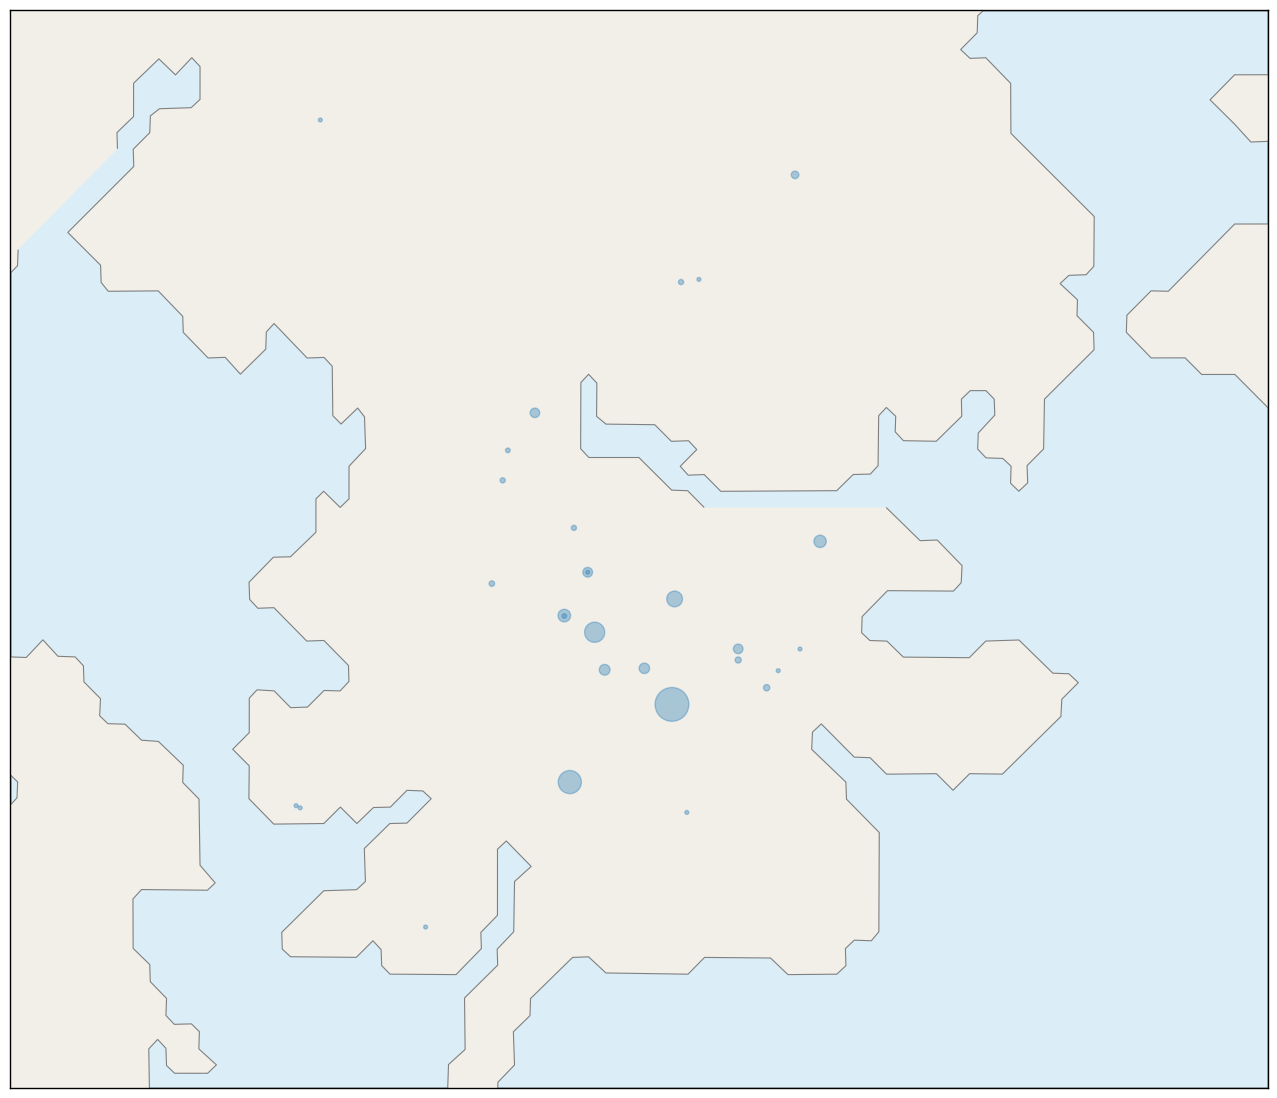

In [16]:
fig = plt.figure(figsize=(19, 14))
m = Basemap(projection='gnom', resolution='f',
            width=7000, height=6000,
            lat_0=60.175, lon_0=24.94)

m.drawmapboundary(fill_color="#dbeef7") #sea color
m.fillcontinents(color='#f2efe9', lake_color='#dbeef7') #land color + lakes
m.drawcoastlines(color='gray', linewidth=0.8)

m.scatter(place_data['long'].values,
          place_data['lat'].values,
          latlon=True,
          # Set marker diameter by the number of events
          s=place_data['performanceCount'].apply(lambda x: 8*x**0.5),
          # transparency
          alpha=0.35)

plt.show()

# for _,p in place_data.iterrows():
#   x, y = m(p['long'], p['lat'])
